### Before start, load inference environments, gpu, cuda, ...

In [1]:
from envs import actenv_jupyter, change_exp_dir, make_gpu_mem_reporter
actenv_jupyter(cuda_version="12.5", gcc_version="11", clear_cache=False)

[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.5
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.5',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.5/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-c9d77990917f3102ada88be140d28b038d1dd7c7/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.5/lib64:',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

### Set experiment dir and models' paths

In [2]:
import torch
import os
import yaml

root_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN"
sfe_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS"
medminist_path = '/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets'
med_path = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging'

Paths = {

        'bloodmnist_x1y3_cs1s2': {
            "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pt",
            "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pkl",
            "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/bloodmnist_Ros/checkpoints/iteration_460000.pt",
            "inverter_pth": sfe_root + "/experiments/inverter/bloodmnist/fse_inverter_train_002/iteration_100000.pt",
            #"sfe_path": sfe_root + "/experiments/fse_cs_editor_train/bloodmnist/110k_000/iteration_360000.pt",
            "sfe_path": sfe_root + "/experiments/fse_cs_editor_train_new/bloodmnist/bloodmnist_x1y3_Reg_cs1s2_001/iteration_340000.pt"
        },

        'bloodmnist_x1y6_cs1s2': {
            "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pt",
            "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pkl",
            "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/bloodmnist_Ros/checkpoints/iteration_460000.pt",
            "inverter_pth": sfe_root + "/experiments/inverter/bloodmnist/fse_inverter_train_002/iteration_100000.pt",
            #"sfe_path": sfe_root + "/experiments/fse_cs_editor_train/bloodmnist/110k_000/iteration_360000.pt",
            "sfe_path": sfe_root + "/experiments/fse_cs_editor_train_new/bloodmnist/bloodmnist_x1y6_Reg_cs1s2_001/iteration_340000.pt"
        }


        }


change_exp_dir(sfe_root)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


model_name = 'bloodmnist_x1y6_cs1s2'
data_name = 'bloodmnist_x1y6'

sfe_ckpt_path = Paths[model_name]["sfe_path"]

# Load config.yaml
config_yaml_path = os.path.join(os.path.dirname(sfe_ckpt_path), "config.yaml")
from omegaconf import OmegaConf
config = OmegaConf.load(config_yaml_path)

config.model.w_space_encoder = "pSp"
config.model.checkpoint_path = sfe_ckpt_path
# config.model.pSp_cs_path = Paths[model_name]["pSp_cs_path"]
config.model.pSp_path = Paths[model_name]["pSp_path"]
config.model.batch_size = 4  # Set batch size for inference

config.model.channel_multiplier = 1
config.data.dataset = data_name

# Pretty YAML (my favorite)
from omegaconf import OmegaConf
print(OmegaConf.to_yaml(config))



cwd: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS
Using device: cuda
exp:
  config_dir: configs
  config: fse_cs_editor_train.yaml
  exp_dir: ./experiments/
  name: fse_cs_editor_train_new/bloodmnist/bloodmnist_x1y6_Reg_cs1s2
  seed: 1
  root: .
  wandb: false
  wandb_project: sfe
  domain: human_faces
  exp_type: ffhq_glasses
data:
  data_dir: ???
  dataset: bloodmnist_x1y6
  transform: face_256
  special_idx: -1
train:
  train_runner: fse_editor_cs1s2
  inverter_optimizer: ranger
  encoder_optimizer: ranger
  disc_optimizer: adam
  resume_path: ''
  val_metrics:
  - msssim
  - lpips
  - l2
  - fid
  start_step: 300000
  steps: 500000
  log_step: 2000
  checkpoint_step: 10000
  val_step: 2000
  train_dis: true
  train_disc_edit: false
  dis_train_start_step: 45000
  bs_used_before_adv_loss: 8
  disc_edits: []
  direction: two_directions
model:
  method: fse_full
  device: '0'
  batch_size: 4
  workers: 4
  checkpoint_path: /home/ids/

In [3]:
from envs import make_gpu_mem_reporter
print_memory = make_gpu_mem_reporter(gpu_index=0, clear_cache_on_setup=True)

print_memory("Before loading model")

from runners.simple_runner import SimpleRunner
runner = SimpleRunner(config=config)
sfe_model = runner.inference_runner
device = sfe_model.device

sfe_model.method.train()

print_memory("After loading model")


[Before loading model]
  - PyTorch Allocated : 0.00 GB
  - PyTorch Reserved  : 0.00 GB
  - Total GPU Used    : 22.36 GB / 40.00 GB

Device: cuda:0
[DEBUG----------------------------] channel_multiplier = 1
[DEBUG----------------------------] stylegan_size = 256
n_styles:  14
Using pSp as w encoder, loading pSp-cs model ....
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/bloodmnist_Ros/checkpoints/iteration_460000.pt
Loading c_s1s2 mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bloodmnist/bloodmnist_x1y6_Reg_cs1s2/checkpoints/iteration_80000.pt
Loading discriminator from /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pkl
✅ pkl loaded via legacy_load
✅ load_disc_any(module->ada): loaded all 64 keys (no mismatch).
✅ discriminator loaded from MODULE (re-instantiated RGB)
Loadin

In [4]:
from torchvision.utils import save_image
from utils.common_utils import tensor2im, get_keys, visualize_batch_grid
from inference_ipynb.inference_funcs import get_latents_cs1s2, calculate_delta_by_latent, recon_by_latent_w, recon_by_delta, configure_datasets, preprocess_image, get_random_seeds
import shutil
from tqdm import tqdm
import torch
import torch.nn.functional as F


def inference(
    sfe_model,
    test_bg_dataloader,
    test_t_dataloader,
    idx,
    vis_mode="row",
    num_pairs=4,
):
    """
    vis_mode:
        - 'row': paper-style visualization (X on top, Y below)
        - 'col': column-wise visualization (X/Y side by side, multiple rows)
    """

    with torch.no_grad():
        for batch_idx, (batch_bg, batch_t) in tqdm(
            enumerate(zip(test_bg_dataloader, test_t_dataloader)),
            total=len(test_bg_dataloader)
        ):
            X = batch_bg.to(device).float()
            Y = batch_t.to(device).float()

            X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
            Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

            # ---- latent decomposition ----
            c_x, s_x1, s_x2, c_y, s_y1, s_y2 = get_latents_cs1s2(X_resh, Y_resh, sfe_model)
            # s_x = torch.zeros_like(s_x)
            recon_w_X = recon_by_latent_w(c_x + s_x1, sfe_model)
            recon_w_Y = recon_by_latent_w(c_y + s_y2, sfe_model)

            swap_w_X2Y = recon_by_latent_w(c_x + s_y2, sfe_model)
            swap_w_Y2X = recon_by_latent_w(c_y + s_x1, sfe_model)

            recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
            recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

            delta_x2y = calculate_delta_by_latent(c_x + s_x1 + s_x2, c_x + s_y1 + s_y2, sfe_model)
            delta_y2x = calculate_delta_by_latent(c_y + s_y1 + s_y2, c_y + s_x1 + s_x2, sfe_model)
            swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
            swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)

            break  # only visualize first batch

    # ==========================================================
    # Visualization
    # ==========================================================
    
    if vis_mode == "row":
        # -------- paper-style: rows = {X, Y}, cols = operations --------
        row1 = torch.stack(
            [X[idx], recon_w_X[idx], swap_w_X2Y[idx], recon_f_X[idx], swap_f_X2Y[idx]],
            dim=0
        )
        row2 = torch.stack(
            [Y[idx], recon_w_Y[idx], swap_w_Y2X[idx], recon_f_Y[idx], swap_f_Y2X[idx]],
            dim=0
        )

        columns = [torch.stack([row1[i], row2[i]], dim=0) for i in range(len(row1))]

        visualize_batch_grid(
            image_batches=columns,
            titles=["Input", "Recon W", "Swap W", "Recon F", "Swap F"],
            save_path=None
        )

    elif vis_mode == "col":
        # -------- debug-style: X / Y columns, multiple rows --------
        for i in range(num_pairs):
            col_X = torch.stack(
                [X[i], recon_f_X[i], swap_f_X2Y[i]],
                dim=0
            )
            col_Y = torch.stack(
                [Y[i], recon_f_Y[i], swap_f_Y2X[i]],
                dim=0
            )

            columns = [col_X, col_Y]
            titles = [f"X #{i}", f"Y #{i}"]

            visualize_batch_grid(
                image_batches=columns,
                titles=titles,
                save_path=None
            )

    else:
        raise ValueError(f"Unknown vis_mode: {vis_mode}")


## Image qualitative evaluation

Random seed: 14498
Loading dataset
Using dataset: bloodmnist_x1y6


  0%|          | 0/117 [00:00<?, ?it/s]


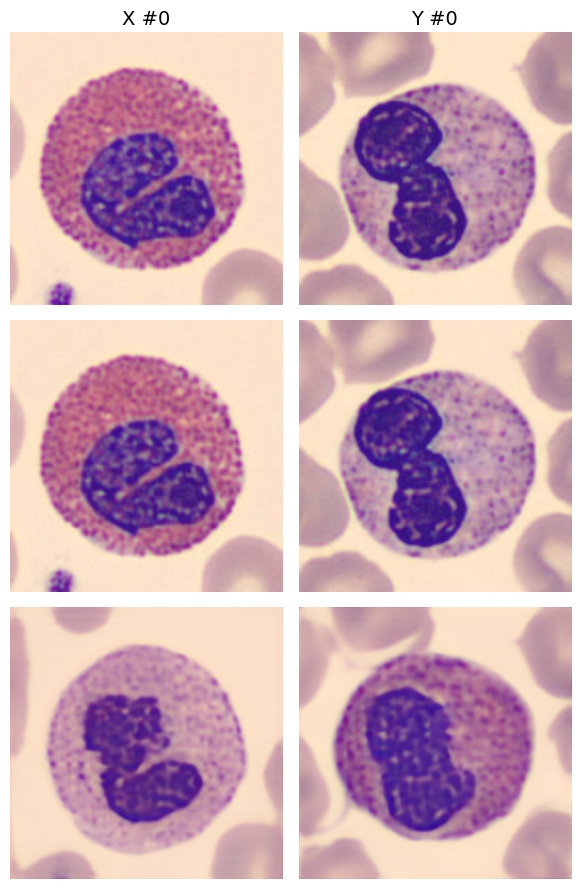

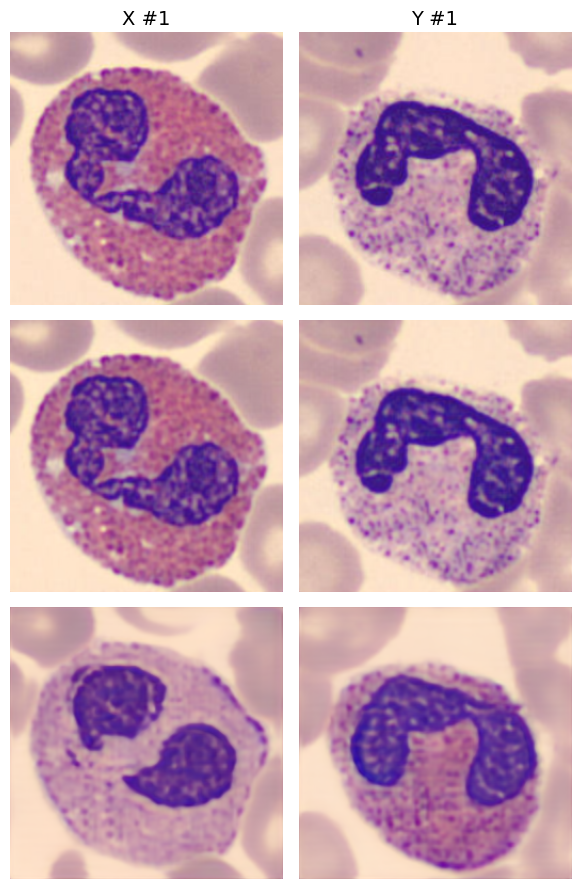

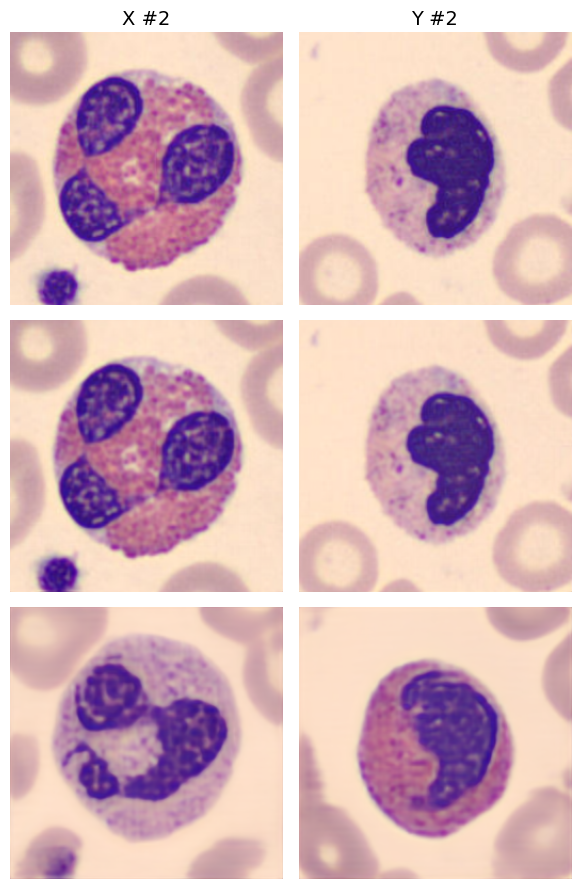

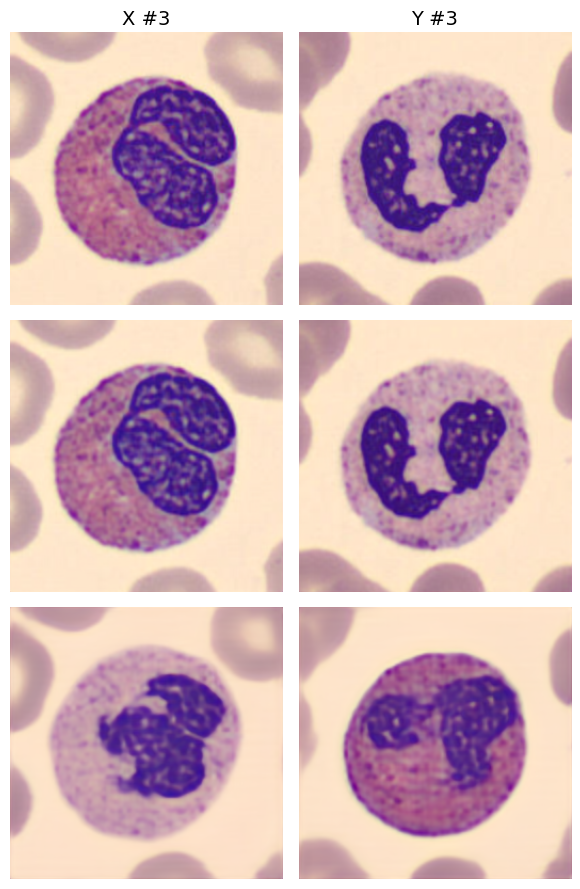

In [6]:
seed = get_random_seeds()
#seed = 18743 17786
# === Get data ===
# sfe_model.config.data.dataset = 'bloodmnist'

test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=True)


%matplotlib inline
inference(sfe_model, test_bg_dataloader, test_t_dataloader, idx=0, vis_mode="col", num_pairs=4)



# Image quantitative evaluation

In [7]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===

ds_name = sfe_model.config.data.dataset
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name =ds_name)

exp_name = f"Ours_octmnist/{sfe_model.config.train.train_runner}/images/{ds_name}"

save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/{exp_name}_Reg"



max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

image_paths = ['real_X', 'real_Y', 'recon_w_X', 'recon_w_Y', 'swap_w_Y2X', 'swap_w_X2Y', 'recon_f_X', 'recon_f_Y', 'swap_f_X2Y', 'swap_f_Y2X']

for path in image_paths:
    dir_path = os.path.join(save_image_dir, path)
    os.makedirs(dir_path)


with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        c_x, s_x1, s_x2, c_y, s_y1, s_y2 = get_latents_cs1s2(X_resh, Y_resh, sfe_model)
        # s_x = torch.zeros_like(s_x)
        recon_w_X = recon_by_latent_w(c_x + s_x1, sfe_model)
        recon_w_Y = recon_by_latent_w(c_y + s_y2, sfe_model)

        swap_w_X2Y = recon_by_latent_w(c_x + s_y2, sfe_model)
        swap_w_Y2X = recon_by_latent_w(c_y + s_x1, sfe_model)

        recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
        recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

        delta_x2y = calculate_delta_by_latent(c_x + s_x1 + s_x2, c_x + s_y1 + s_y2, sfe_model)
        delta_y2x = calculate_delta_by_latent(c_y + s_y1 + s_y2, c_y + s_x1 + s_x2, sfe_model)
        swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)

        # collect (keys align with image_paths)
        images = {
            "real_X": X,
            "real_Y": Y,
            "recon_w_X": recon_w_X,
            "recon_w_Y": recon_w_Y,
            "recon_f_X": recon_f_X,
            "recon_f_Y": recon_f_Y,
            "swap_w_X2Y": swap_w_X2Y,
            "swap_w_Y2X": swap_w_Y2X,
            "swap_f_X2Y": swap_f_X2Y,
            "swap_f_Y2X": swap_f_Y2X,
        }



        # de-normalize / postprocess per tensor (skip None)
        images = {k: (None if v is None else preprocess_image(v)) for k, v in images.items()}

        # save all groups
        B = next(v.size(0) for v in images.values() if v is not None)
        for i in range(B):
            idx = batch_idx * B + i
            for key, tensor in images.items():
                if tensor is None or tensor.ndim != 4 or i >= tensor.size(0):
                    continue
                img_i = tensor[i].detach().cpu().clamp(0, 1)  # safety clamp
                save_image(img_i, os.path.join(save_image_dir, key, f"{idx}.png"))

    print(f"Results images saved to {save_image_dir}")

Random seed: 12420
Loading dataset
Using dataset: bloodmnist_x1y6


100%|██████████| 117/117 [04:17<00:00,  2.20s/it]

Results images saved to /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Ours_octmnist/fse_editor_cs1s2/images/bloodmnist_x1y6_Reg


## Latent separation evaluation

In [8]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===
ds_name = config.data.dataset #= 'bloodmnist_x1y6'
model_name = ds_name
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name=ds_name)
# test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False)
exp_name = f"Ours_bloodmnist/{sfe_model.config.train.train_runner}/latents/{ds_name}"

save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/{exp_name}_Reg"


max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

# Prepare directories for saving images
latent_paths = ['latents_x', 'latents_y']

for path in latent_paths:
    dir_path = os.path.join(save_image_dir, path)
    if os.path.exists(dir_path):
            shutil.rmtree(dir_path)
    os.makedirs(dir_path)


sfe_model.method.train()
with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        c_x, s_x1, s_x2, c_y, s_y1, s_y2 = get_latents_cs1s2(X_resh, Y_resh, sfe_model)

        # Group latents for background (x) and target (y)
        latents = {
            "x": {"c": c_x, "s1": s_x1, "s2": s_x2},
            "y": {"c": c_y, "s1": s_y1, "s2": s_y2},
        }

        # Save latents per sample
        batch_size = X.size(0)
        for i in range(batch_size):
            idx = batch_idx * batch_size + i
            for key in ["x", "y"]:
                save_path = os.path.join(save_image_dir, f"latents_{key}", f"latent_{key}_{idx}.pt")
                torch.save({k: v[i].cpu() for k, v in latents[key].items()}, save_path)


Random seed: 1037
Loading dataset
Using dataset: bloodmnist_x1y6


100%|██████████| 117/117 [00:20<00:00,  5.82it/s]


## Interpolation

Random seed: 3594
Loading dataset
Using dataset: bloodmnist_x1y3


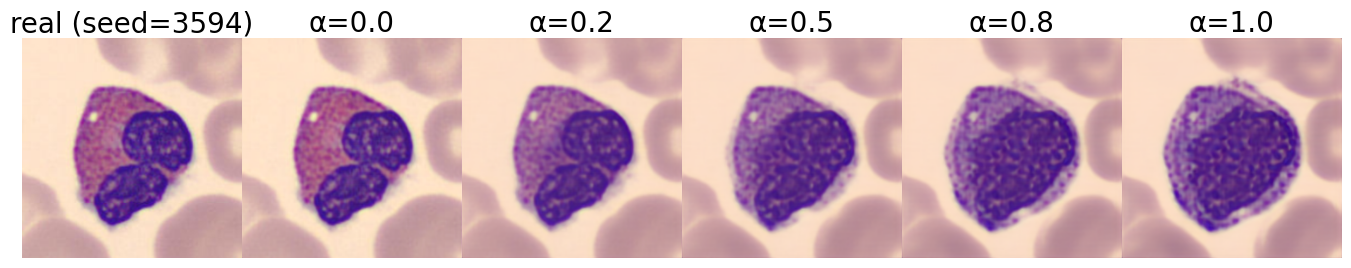

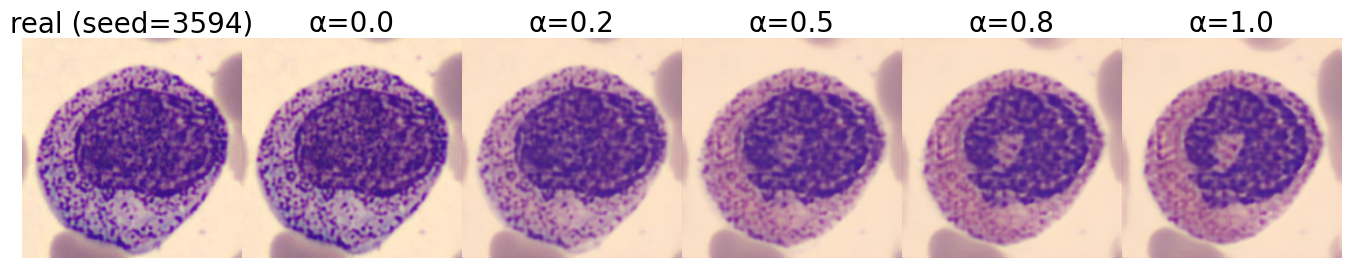

In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# =========================
# Seed & Data
# =========================
seed = get_random_seeds()
# seed = 13477

test_bg_dataloader, test_t_dataloader = configure_datasets(
    sfe_model.config,
    test_images=True,
    seed=seed,
    shuffle=True
)

batch_bg = next(iter(test_bg_dataloader))
batch_t  = next(iter(test_t_dataloader))

# =========================
# Alpha Range
# =========================
alphas_x = torch.linspace(0, 1, steps=5)
alphas_y = torch.linspace(0, 1, steps=5)

titles_x = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_x]
titles_y = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_y]

# =========================
# Prepare Reconstructions
# =========================
recon_X_alpha = []
recon_Y_alpha = []

with torch.no_grad():
    sfe_model.method.train()

    X = batch_bg.to(device).float()
    Y = batch_t.to(device).float()

    X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
    Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

    # ===== latents =====
    c_x, s_x1, s_x2, c_y, s_y1, s_y2 = get_latents_cs1s2(
        X_resh, Y_resh, sfe_model
    )

    # ===== add REAL images first =====
    recon_X_alpha.append(X_resh)
    recon_Y_alpha.append(Y_resh)

    # ===== deltas =====
    delta_x2y = calculate_delta_by_latent(
        c_x + s_x1 + s_x2,
        c_x + s_y1 + s_y2,
        sfe_model
    )

    delta_y2x = calculate_delta_by_latent(
        c_y + s_y1 + s_y2,
        c_y + s_x1 + s_x2,
        sfe_model
    )

    # ===== alpha interpolation =====
    for alpha_x, alpha_y in zip(alphas_x, alphas_y):
        swap_f_X2Y = recon_by_delta(
            X_resh, alpha_x * delta_x2y, sfe_model=sfe_model
        )
        swap_f_Y2X = recon_by_delta(
            Y_resh, alpha_y * delta_y2x, sfe_model=sfe_model
        )

        recon_X_alpha.append(swap_f_X2Y)
        recon_Y_alpha.append(swap_f_Y2X)

# =========================
# Crop Utils
# =========================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))

def tensor_to_cropped_img(t, crop_cfg):
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()

    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)

    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)

# =========================
# Crop Config
# =========================
h = 0
dist = 0
crop_cfg = dict(
    w_l=dist + h,
    w_r=dist - h,
    h_top=dist,
    h_bot=dist
)

# =========================
# Visualization
# =========================
num_images = len(recon_X_alpha)   # == len(titles_x)
col_spacing = 0.0
title_height = 0.05
total_width = 1.0
img_width = (total_width - (num_images - 1) * col_spacing) / num_images

%matplotlib inline

# --- FIGURE 1: X row ---
fig_x = plt.figure(figsize=(num_images * 2.2, 2.5))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_x.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_X_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titles_x[i], fontsize=20, pad=2)

plt.show()

# --- FIGURE 2: Y row ---
fig_y = plt.figure(figsize=(num_images * 2.2, 2.5))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_y.add_axes([left, 0, img_width, 1])

    img = tensor_to_cropped_img(recon_Y_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titles_y[i], fontsize=20, pad=2)

plt.show()
